# BÀI TẬP: MEDICAL INSURANCE COST
**Nguồn:** kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset



## Setup

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')


csv_path = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [3]:
# TODO
print("Data size: ",df.shape)
print("Data column: ", df.columns)
print("Data types:\n",df.dtypes)


Data size:  (1338, 7)
Data column:  Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')
Data types:
 age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


## A.2. Missing values & Duplicate data

In [4]:
# TODO
print(df.isnull().sum())
print("-------------------")
print(df.duplicated().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
-------------------
1


## A.3. Invalid values

In [5]:
# TODO
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

## A.4. Create a new column
Tạo cột `bmi_group`: Normal (<25), Overweight (25-30), Obese (>=30).

In [6]:
# TODO
conditions = [df['bmi'] < 25, (df['bmi'] >= 25) & (df['bmi'] < 30), df['bmi'] >= 30
]

choices = ['Normal', 'Overweight', 'Obese']

df['bmi_group'] = np.select(conditions, choices, default= 'Unknown')

df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_group
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Overweight


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [7]:
df.mean(numeric_only=True)

age            39.207025
bmi            30.663397
children        1.094918
charges     13270.422265
dtype: float64

In [8]:
df.median(numeric_only=True)

age           39.000
bmi           30.400
children       1.000
charges     9382.033
dtype: float64

In [9]:
df.mode()

,age,sex,bmi,children,smoker,region,charges,bmi_group
0,18,male,32.3,0,no,southeast,1639.5631,Obese


## Group 2 — Dispersion

In [10]:
# TODO
df.std(numeric_only=True)

age            14.049960
bmi             6.098187
children        1.205493
charges     12110.011237
dtype: float64

In [11]:
range = df.max(numeric_only=True) - df.min(numeric_only=True)

range

age            46.00000
bmi            37.17000
children        5.00000
charges     62648.55411
dtype: float64

In [12]:
iqr = df.quantile(0.75, numeric_only=True)-df.quantile(0.25, numeric_only=True)

iqr

age            24.000000
bmi             8.397500
children        2.000000
charges     11899.625365
dtype: float64

## Group 3 — Location and Shape

In [13]:
# TODO
df.quantile([0.25, 0.5, 0.75], numeric_only=True)

,age,bmi,children,charges
0.25,27.0,26.29625,0.0,4740.287150
0.50,39.0,30.40000,1.0,9382.033000
0.75,51.0,34.69375,2.0,16639.912515


In [14]:
df.skew(numeric_only=True)

age         0.055673
bmi         0.284047
children    0.938380
charges     1.515880
dtype: float64

In [15]:
df.kurtosis(numeric_only=True)

age        -1.245088
bmi        -0.050732
children    0.202454
charges     1.606299
dtype: float64

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Người hút thuốc trả chi phí cao hơn bao nhiêu lần so với người không hút, và có đồng đều giữa các vùng không?

Chi phí trung bình:
smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

Người hút thuốc trả cao hơn: 3.8 lần

Chi phí theo từng vùng:
smoker              no           yes     ratio
region                                        
northeast  9165.531672  29673.536473  3.237514
northwest  8556.463715  30192.003182  3.528561
southeast  8032.216309  34844.996824  4.338155
southwest  8019.284513  32269.063494  4.023933


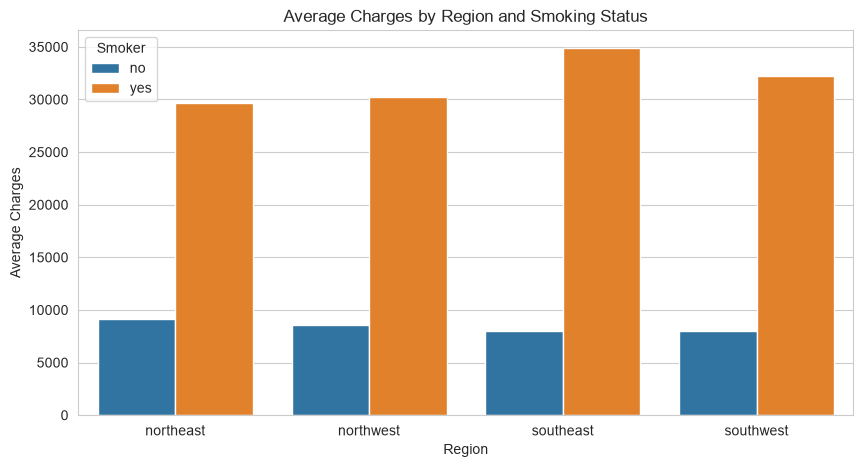

In [16]:
# TODO
smoker_mean = df.groupby('smoker')['charges'].mean()

ratio = smoker_mean['yes'] / smoker_mean['no']

print("Chi phí trung bình:")
print(smoker_mean)
print("\nNgười hút thuốc trả cao hơn:", round(ratio, 2), "lần")

region_smoker = df.groupby(['region', 'smoker'])['charges'].mean().unstack()
region_smoker['ratio'] = region_smoker['yes'] / region_smoker['no']

print("\nChi phí theo từng vùng:")
print(region_smoker)

region_smoker = df.groupby(['region', 'smoker'])['charges'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=region_smoker, x='region', y='charges', hue='smoker')

plt.title('Average Charges by Region and Smoking Status')
plt.xlabel('Region')
plt.ylabel('Average Charges')
plt.legend(title='Smoker')

plt.show()


## Câu hỏi 2: BMI có tương quan với chi phí mạnh hơn ở nhóm hút thuốc hay không hút thuốc?

Tương quan BMI - charges ở người hút thuốc: 0.806
Tương quan BMI - charges ở người không hút thuốc: 0.084
=> BMI tương quan với chi phí mạnh hơn ở nhóm hút thuốc.


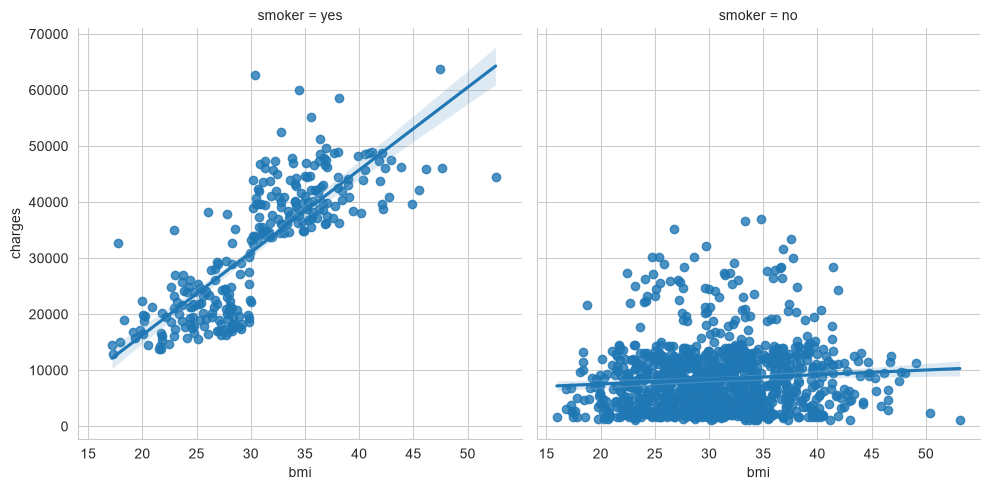

In [17]:
# TODO
corr_smoker = df[df['smoker'] == 'yes']['bmi'].corr(
    df[df['smoker'] == 'yes']['charges']
)

corr_non_smoker = df[df['smoker'] == 'no']['bmi'].corr(
    df[df['smoker'] == 'no']['charges']
)

print("Tương quan BMI - charges ở người hút thuốc:", round(corr_smoker, 3))
print("Tương quan BMI - charges ở người không hút thuốc:", round(corr_non_smoker, 3))

if abs(corr_smoker) > abs(corr_non_smoker):
    print("=> BMI tương quan với chi phí mạnh hơn ở nhóm hút thuốc.")
else:
    print("=> BMI tương quan với chi phí mạnh hơn ở nhóm không hút thuốc.")

sns.lmplot(data=df, x='bmi', y='charges', col='smoker', height=5, aspect=1)

plt.show()


## Câu hỏi 3: Vùng nào có chi phí bảo hiểm trung bình cao nhất?

Chi phí trung bình theo vùng:
region
southeast    14735.411438
northeast    13406.384516
northwest    12417.575374
southwest    12346.937377
Name: charges, dtype: float64

Vùng có chi phí trung bình cao nhất: southeast
Chi phí trung bình: 14735.41


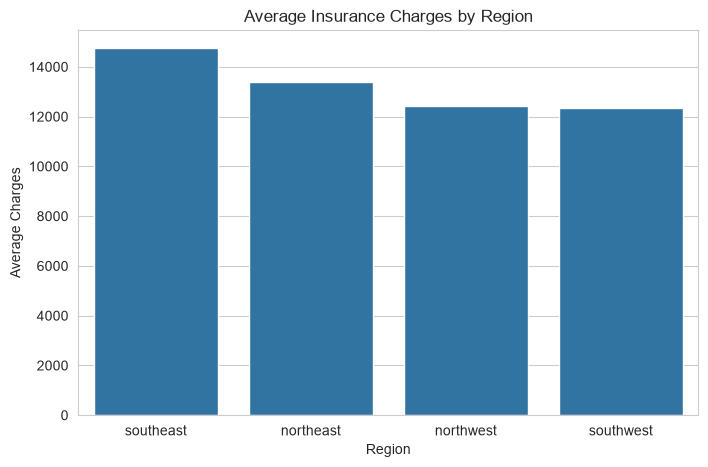

In [18]:
# TODO
region_mean = df.groupby('region')['charges'].mean().sort_values(ascending=False)

print("Chi phí trung bình theo vùng:")
print(region_mean)

print("\nVùng có chi phí trung bình cao nhất:", region_mean.idxmax())
print("Chi phí trung bình:", round(region_mean.max(), 2))

region_mean = (df.groupby('region')['charges'].mean().sort_values(ascending=False).reset_index())

plt.figure(figsize=(8, 5))

sns.barplot(data=region_mean, x='region', y='charges')

plt.title('Average Insurance Charges by Region')
plt.xlabel('Region')
plt.ylabel('Average Charges')
plt.show()


## Câu hỏi 4: Số lượng con cái có làm tăng chi phí bảo hiểm không?

   children       charges
0         0  12365.975602
1         1  12731.171832
2         2  15073.563734
3         3  15355.318367
4         4  13850.656311
5         5   8786.035247


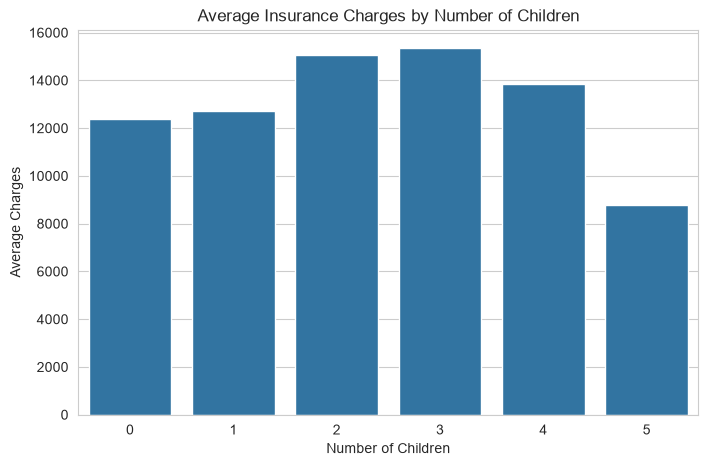

In [19]:
# TODO
children_mean = (df.groupby('children')['charges'].mean().reset_index())
print(children_mean)

plt.figure(figsize=(8, 5))

sns.barplot(data=children_mean, x='children', y='charges')

plt.title('Average Insurance Charges by Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Average Charges')
plt.show()


## Câu hỏi 5: Tuổi có tương quan với chi phí bảo hiểm không?

Tương quan age - charges: 0.299


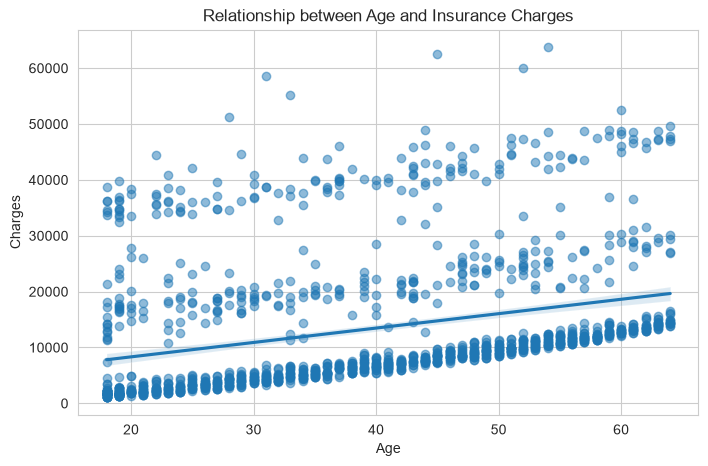

In [20]:
# TODO
corr_age = df['age'].corr(df['charges'])

print("Tương quan age - charges:", round(corr_age, 3))

plt.figure(figsize=(8, 5))

sns.regplot(data=df, x='age', y='charges', scatter_kws={'alpha': 0.5})

plt.title('Relationship between Age and Insurance Charges')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

*(Viết insight của bạn vào đây...)*
### Phần A — Data Profiling

Dữ liệu có chất lượng khá tốt, không phát hiện giá trị thiếu hoặc dòng dữ liệu bị trùng. Các biến số như `age`, `bmi`, `children`, `charges` cũng không xuất hiện các giá trị vô lý theo các điều kiện đã kiểm tra. Vì vậy, dữ liệu có thể được sử dụng trực tiếp cho các bước phân tích tiếp theo mà không cần xử lý thiếu hoặc loại bỏ dữ liệu trùng.

### Phần B — Descriptive Statistics

Các biến định lượng như tuổi, BMI, số con và chi phí bảo hiểm có mức độ phân bố khác nhau. Đặc biệt, `charges` có sự phân tán lớn và phân phối lệch, cho thấy tồn tại một nhóm khách hàng có chi phí bảo hiểm cao hơn đáng kể so với phần lớn dữ liệu. Trong khi đó, các biến như `age` và `bmi` có phân bố ổn định hơn.

### Phần C — Phân tích câu hỏi

Kết quả phân tích cho thấy tình trạng hút thuốc có liên quan rõ rệt đến chi phí bảo hiểm, khi người hút thuốc có xu hướng trả chi phí cao hơn người không hút thuốc. BMI cũng có mối liên hệ với chi phí và mức độ này có thể khác nhau giữa nhóm hút thuốc và không hút thuốc. Chi phí bảo hiểm trung bình có sự khác biệt giữa các vùng. Số lượng con không làm chi phí tăng đều, vì chi phí tăng từ nhóm 0 đến khoảng 3 con nhưng giảm ở nhóm 4–5 con. Ngoài ra, tuổi có xu hướng tương quan thuận với chi phí bảo hiểm, tức là tuổi càng cao thì chi phí thường có xu hướng tăng.
